This Jupyter Notebook makes use of the `affiliation-builder` package to build an affiliation network from TEI-XML `<event>` data (converted to JSON using the [listEvent-to-json](https://github.com/timofruehwirth/event-network/tree/main/xslt) stylesheet). This serves two purposes. First, the Notebook is intended to demonstrate the Python utility in a real-world use case. Second, being run on the XSLT-transformed TEI `<listEvent>` of the [Auden Musulin Papers](https://www.oeaw.ac.at/acdh/research/literary-studies/research/authors-editions/auden-musulin-papers) project (2021-2024), it tentatively outlines the contours of network-analysis-supported research of British-American poet W. H. Auden's biographical environment during his Austrian period 1957-1973.

Because the data originate in the digital edition of Auden's correspondence with Welsh-Austrian writer Stella Musulin and of her two previously unpublished Auden memoirs, a strong bias, resulting in a tendency toward (over-)emphasizing the memoirist's position in Auden's network, is expected. A less distorted `<listEvent>` dataset is currently being developed in the context of the [Auden in Austria Digital](https://www.oeaw.ac.at/acdh/research/literary-studies/research/authors-editions/auden-in-austria-digital) project (2024-2027), which will provide a solid basis for network research.

#### 1 Install packages

In [1]:
%pip install -q networkx pandas matplotlib affiliation-builder  # line magic for Notebook-kernel installation; install quietly

Note: you may need to restart the kernel to use updated packages.


#### 2 Import dependencies

In [2]:
import logging

# network analysis
import networkx as nx
from networkx.algorithms import bipartite

# data manipulation
import pandas as pd

# visualization
import matplotlib.pyplot as plt

# affiliation-builder
from affiliation_builder import build

#### 3 Configure logging

In [3]:
logging.getLogger('affiliation_builder').setLevel(logging.INFO)  # retrieve package logger; include INFO-level log messages
logging.getLogger('affiliation_builder').addHandler(logging.StreamHandler())  # attach handler for console output

#### 4 Build bipartite network from JSON data

This construction of a bipartite network loads both person and organization data as nodes of the same set. This is done against the background of a research interest in Auden's Austrian environment, understood as comprising both the people and the institutions affiliated with the events in which Auden participated. In the projected (unipartite) network, person-person edges will therefore represent co-attendance; person-organization edges will connect people attending events with institutions identified as organizing or hosting those events; organization-organization edges will map institutional co-affiliation. The metrics calculated further below (density, components, weighted degree) aggregate over all node and edge types.

In [4]:
G_bipartite = build(
    json_path="../json/amp-events.json",  # JSON data source
    node_set_0_key="listEvent",  # top-level JSON key wrapping events
    node_set_1_keys=["listPerson", "org"],  # JSON keys for affiliated entities
    identifier_key="xml:id",  # JSON key for event ID
    node_set_1_identifier_key="sameAs"  # JSON key for ID of affiliated entity
)

Affiliation network builder started
JSON source: ../json/amp-events.json
Node-set-0 key: 'listEvent'
Node-set-1 keys: ['listPerson', 'org']
Identifier key: 'xml:id'
Node-set-1 identifier key: 'sameAs'
Local file path detected: ../json/amp-events.json
Local JSON file successfully loaded
Wrapped object format with 105 items in 'listEvent' detected
NetworkX graph initialized
Bipartite network construction complete
Total edges (affiliations): 245
Total nodes: 188
Node set 0 (listEvent): 105 nodes
Node set 1 (['listPerson', 'org']): 83 nodes
✓ Graph structure is valid bipartite


#### 5 Filter bipartite graph

##### 5.1 Set up filter

In [5]:
def filter_by_date(G_bipartite, start_date, end_date):
    """
    Filters bipartite graph to events within a date range.
    Uses notBefore-iso attribute (event start date) for filtering;
    events spanning beyond filter range are included if start date is within.
    
    Parameters
    ----------
    G_bipartite : networkx.Graph
        Bipartite affiliation graph
    start_date : str
        Start date in YYYY-MM-DD ISO format
    end_date : str
        End date in YYYY-MM-DD ISO format
    
    Returns
    -------
    networkx.Graph
        Filtered bipartite graph
    """
    events = []

    for node, data in G_bipartite.nodes(data=True):  # loop through nodes with their IDs and attributes
        if data.get("bipartite") == 0:  # get events
            event_date = data.get("notBefore-iso", "")[:10]  # get event start date attribute
            if event_date and start_date <= event_date <= end_date:  # check event start date is in range
                events.append(node)  # add event node ID to list
    
    entities = set()

    for event in events:
        entities.update(G_bipartite.neighbors(event))  # add entity node IDs to set
    
    nodes = set(events) | entities  # unify relevant event and entity node IDs in single set
    
    return G_bipartite.subgraph(nodes).copy()  # return filtered view and copy as independent graph


##### 5.2 Apply filter

In [6]:
G_filtered = filter_by_date(G_bipartite, "1957-01-01", "1973-12-31")

entities = {n for n, d in G_filtered.nodes(data=True) if d["bipartite"] == 1}  # create set of entity node IDs

#### 6 Bipartite network visualization

This minimal visualization illustrates the basic structure of the bipartite network, in which two sets of nodes, events (orange) and entities (persons and organizations, blue), are connected by affiliation edges.

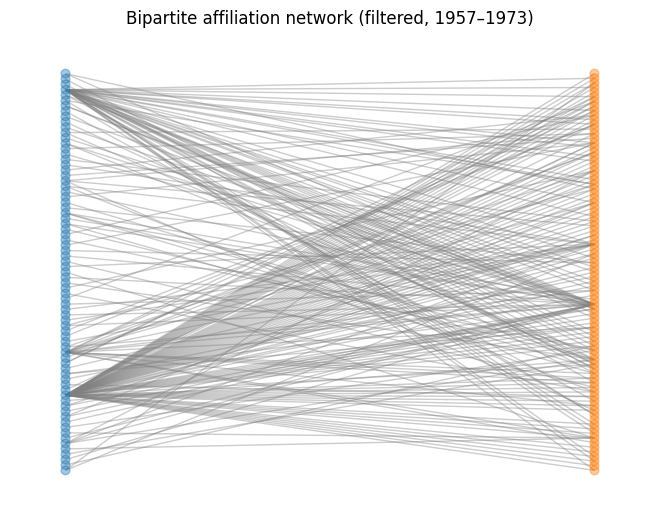

In [7]:
pos = nx.bipartite_layout(G_filtered, entities)  # call bipartite layout helper, pass entities as one column
plt.figure()  # plot bipartite network
nx.draw(G_filtered, pos, node_size=40, node_color=["C0" if n in entities else "C1" for n in G_filtered.nodes()], edge_color="gray", alpha=0.4, with_labels=False)  # color by node type, set 40% opacity
plt.title("Bipartite affiliation network (filtered, 1957–1973)")
plt.show()

#### 7 Unipartite projection

This simple projection creates a one-mode network whose edge weights represent the number of shared events between entity nodes. In such a network, every event contributes equally regardless of its size, so that single large events create many weight-1 edges.

An alternative approach, Newman's (2001) collaboration-weighted projection, re-weights each event's contribution by its inverse size to reduce the influence of large events (see [collaboration_weighted_projected_graph](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.bipartite.projection.collaboration_weighted_projected_graph.html)). The simpler approach is followed here for more direct representation of, and cross-checkability against, the source data: weight equals the number of shared events. However, the Newman projection is used further below to mitigate the large-event effect on network visualization.

In [8]:
G = bipartite.weighted_projected_graph(G_filtered, entities)  # create entity network with weighted edges

print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")  # report graph size

75 nodes, 407 edges


#### 8 Extract ego network

In [9]:
ego = 'amp_person_1'  # define ego

G_ego = nx.ego_graph(G, ego)  # extract ego network including alter-alter edges

print(f"{G_ego.number_of_nodes() - 1} alters, {G_ego.number_of_edges()} edges")  # report graph size

print("\ntop 5 edges by weight:")
edges_by_weight = sorted(G_ego.edges(data=True), key=lambda x: x[2]["weight"], reverse=True)  # sort by weight in edge-attribute dictionary
for u, v, d in edges_by_weight[:5]:
    print(f"- {u} — {v}: {d['weight']} shared events")

45 alters, 157 edges

top 5 edges by weight:
- amp_person_1 — amp_person_2: 34 shared events
- amp_person_1 — amp_person_4: 11 shared events
- amp_person_4 — amp_person_2: 8 shared events
- amp_organization_9 — amp_person_1: 3 shared events
- amp_person_3 — amp_person_1: 2 shared events


#### 9 Compute network metrics

##### 9.1 Explore ego network

In [10]:
weights = [d['weight'] for _, _, d in G_ego.edges(data=True)]  # get list of weights from node-node-attributes tuples

print("unique edge weights and their counts in ego network:")
pd.Series(weights).value_counts().sort_index()  # wrap list as pandas Series, count occurrences of each unique weight, sort by weight values

unique edge weights and their counts in ego network:


1     140
2      13
3       1
8       1
11      1
34      1
Name: count, dtype: int64

##### 9.2 Explore alter network

In [11]:
# create stand-alone alter network
G_alters = G_ego.copy()
G_alters.remove_node(ego)

print(f"{G_alters.number_of_nodes()} alters, {G_alters.number_of_edges()} edges")

weights = [d['weight'] for _, _, d in G_alters.edges(data=True)]

print("\nunique edge weights and their counts in alter network:")
pd.Series(weights).value_counts().sort_index()

45 alters, 112 edges

unique edge weights and their counts in alter network:


1    103
2      8
8      1
Name: count, dtype: int64

##### 9.3 Analyze alter network

The following lines of code introduce metrics that may be relevant to an analysis of the biographical (both human and institutional) environment in which W. H. Auden moved during his Austrian period. They also preserve code that has been commented out: clustering and clique-formation measures prove inadequate to the study of affiliation networks, in which edges do not represent close social ties, but map relations of co-affiliation. These now commented-out lines have been retained to draw attention to this specific characteristic of affiliation-network analysis.

In [12]:
# Density: proportion of possible alter-pairs that are actually co-affiliated
# through the same event(s) (actual/possible)
# Low density (close to 0) = alters tend not to be co-affiliated
# High density (close to 1) = alters tend to be co-affiliated
alter_density = nx.density(G_alters)
print(f"alter network density: {alter_density:.3f}")

# Components: number of separate unconnected groups among alters
# 1 = all alters connected by chains of co-affiliation
# >1 = there are groups of alters with no co-affiliation between them
# High number = many unconnected groups of alters linked to the ego
alter_components = nx.number_connected_components(G_alters)
print(f"components among alters: {alter_components}")

# Articulation points: nodes that bridge what would otherwise be disconnected components,
# i.e., their removal would increase the number of components
articulation = list(nx.articulation_points(G_alters))
print(f"articulation points: {len(articulation)} ({', '.join(articulation)})")

# Clustering: proportion of possible interconnections between each node's neighbors (actual/possible)
# 0 = no triangles (loose chains)
# 1 = every pair of alters with a common co-affiliated alter is also co-affiliated
# High clustering = dense groups of co-affiliation, not just chains
# if G_alters.number_of_edges() > 0:  # skip printout if there are no edges
#     alter_clustering = nx.average_clustering(G_alters)
#     print(f"average clustering among alters: {alter_clustering:.3f}")
# Unipartite clustering coefficient removed - artifact of affiliation projection:
# any event with ≥3 participants induces cliques;
# possible alternatives:
# - two-mode/bipartite clustering (Opsahl 2013; Latapy et al. 2008),
# - projection-plus-correction: weighted clustering (Barrat et al. 2004; Onnela et al. 2005;
#   Fagiolo 2007) counting only triangles supported by ≥2 events,
#   and/or z-score against a bipartite configuration-model null.

# Cliques: complete subgraphs where every node connects to every other
# Reveals densely co-affiliated cores within larger components
# cliques = list(nx.find_cliques(G_alters))  # list cliques as lists of node IDs
# largest_clique = max(cliques, key=len)  # get largest clique
# print(f"number of cliques: {len(cliques)}")
# print(f"largest clique: {len(largest_clique)} nodes ({largest_clique})")
# Clique analysis removed - artifact of affiliation projection:
# cliques form automatically when multiple people attend a single event
# alternative: k-core decomposition (Seidman 1983) identifies cohesive subgroups
# where each node has ≥k within-group co-affiliations, filtering out single-event artifacts

# Weighted degree: sum of edge weights (co-affiliation) for each alter
# Higher value = more cumulative co-affiliation of alter with others (reflecting multiple
# co-affiliation with same alters and/or single co-affiliation with multiple alters)
weighted_degree_alters = {node: sum(d['weight'] for _, _, d in G_alters.edges(node, data=True)) for node in G_alters.nodes()}  # create dictionary that maps node IDs to weighted degrees
print("\ntop 5 alters by weighted degree:")
for node, value in sorted(weighted_degree_alters.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"- {node}: {value}")

alter network density: 0.113
components among alters: 10
articulation points: 3 (amp_person_2, amp_person_4, amp_person_152)

top 5 alters by weighted degree:
- amp_person_2: 35
- amp_person_4: 30
- amp_person_137: 19
- amp_person_97: 11
- amp_person_152: 10


#### 10 Visualize ego network

##### 10.1 Prepare visualization data

This first visualization is based on the simple-projection edge weighting: the count of events shared by two nodes drives both the spring-layout position and the edge thickness. Weight is therefore encoded twice (position and thickness), and the highest-weight edge has a shaping influence on both the layout pull (its endpoints are pulled together and the rest of the network rearranges around them) and the width normalization (compressing other widths relative to its own).

Groups linked by a single multi-participant event cluster spatially, because the many weight-1 edges from that event accumulate as collective pull — this is a feature of the projection rather than of repeated co-affiliation.


In [13]:
# map component membership
component_map = {}
for i, component in enumerate(nx.connected_components(G_alters)):  # loop through indexed sets of components
    for node in component:  # loop through nodes in component
        component_map[node] = i  # map node to its component index in dictionary

component_map[ego] = -1  # map ego node to special value

# add weighted degree for ego
weighted_degree_ego = weighted_degree_alters.copy()
weighted_degree_ego[ego] = sum(d['weight'] for _, _, d in G_ego.edges(ego, data=True))  # add ego's weighted degree to dictionary

# normalize weighted degree for visualization
max_wd_alters = max(weighted_degree_alters.values())  # get highest value for alters
node_sizes = [300 + 700 * min(weighted_degree_ego[node] / max_wd_alters, 1) for node in G_ego.nodes()]  # scale ratio to 0-700 points; set base size to 300; cap node scale at 1

colors = [component_map[node] for node in G_ego.nodes()]  # list component membership values in order of nodes in graph

edge_weights = [G_ego[u][v]['weight'] for u, v in G_ego.edges()]  # access dictionary of edge attributes; list edge weights in order of edges in graph

# normalize edge width for visualization
max_weight = max(edge_weights)
edge_widths = [0.5 + 3 * (w / max_weight) for w in edge_weights]  # scale ratio to 0-3; set base width to 0.5

name_map = {n: d.get('persName', d.get('orgName', n)) for n, d in G_ego.nodes(data=True)}  # get person name or organization name or node ID

pos = nx.spring_layout(G_ego, weight='weight', seed=42)  # set layout to spring algorithm based on edge weight; fix random starting positions

##### 10.2 Plot figure

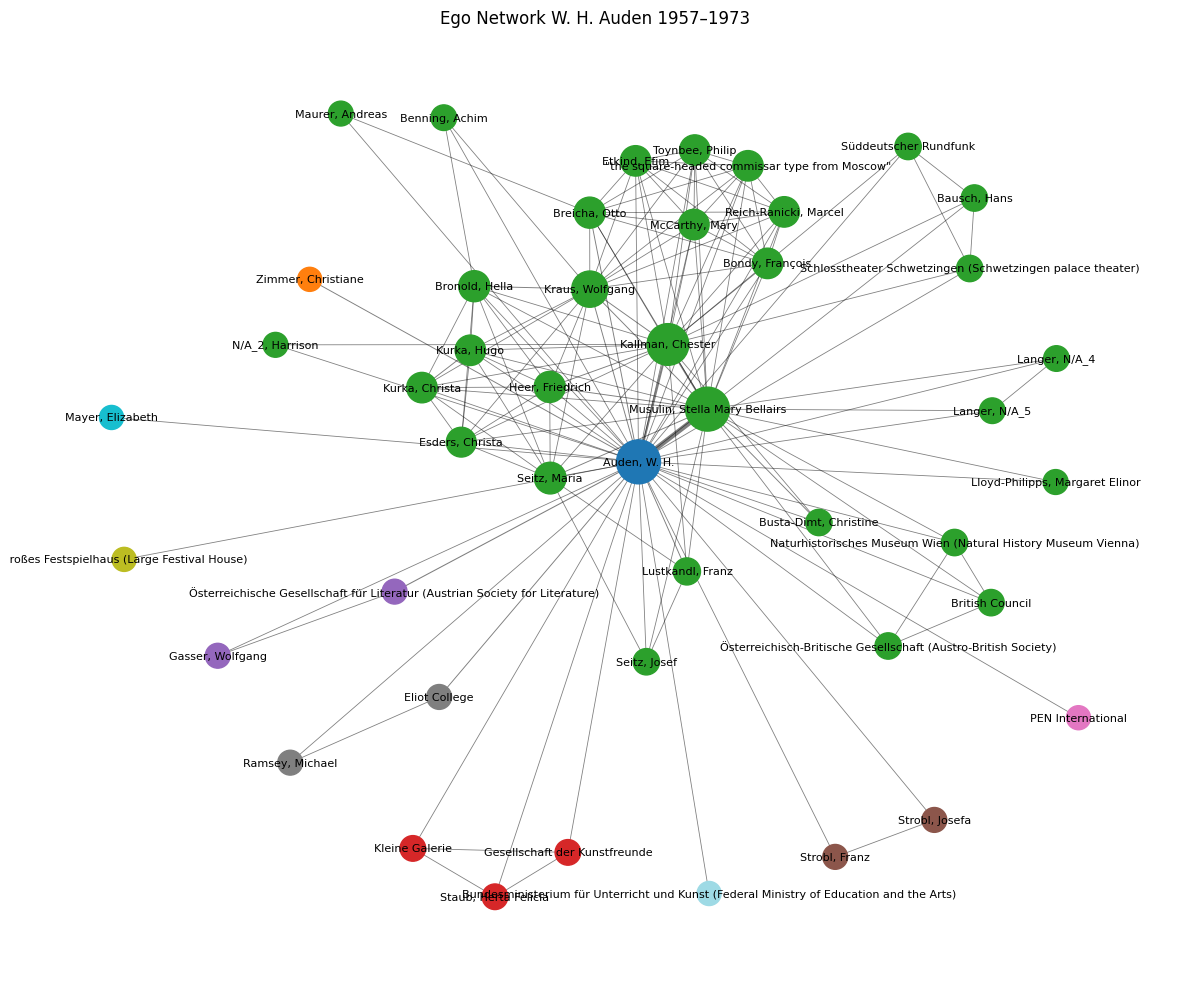

In [14]:
plt.figure(figsize=(12, 10))  # set dimensions to 12 by 10 inches
nx.draw_networkx_nodes(G_ego, pos, node_size=node_sizes, node_color=colors, cmap=plt.cm.tab20)  # set node layout and sizes; set colors via matplotlib colormap
nx.draw_networkx_edges(G_ego, pos, width=edge_widths, alpha=0.5)  # set edge layout and widths; set transparency to 50%
nx.draw_networkx_labels(G_ego, pos, labels=name_map, font_size=8)  # set label layout and size
plt.title("Ego Network W. H. Auden 1957–1973")
plt.axis('off')  # hide coordinate axes
plt.tight_layout()  # adjust margins so that title and nodes are not clipped
plt.show()  # render and display the figure

##### 10.3 Refine layout (Newman-weighted projection)

This alternative visualization uses Newman's (2001) collaboration-weighted projection for layout computation: each event's contribution to a pairwise edge weight is divided by `(k − 1)`, where `k` is the event size, so that single large events exert less pull on the spring algorithm. This is intended to reduce the dense visual clustering of large-event affiliations near the ego. Edge thickness, node size, and coloring continue to use the simple-projection data, keeping them aligned with the analytical section above.

It needs to be noted that spring layouts cannot dissolve cliques topologically (i.e., in terms of network structure). The structural mass of any single multi-participant event remains visible (i.e., even if individual springs are weak, there are multiple separate pulls toward the rest of the clique).

In [15]:
G_newman = bipartite.collaboration_weighted_projected_graph(G_filtered, entities)  # use Newman's collaboration-weighted (unipartite) projection on entities of date-filtered graph

print(f"{G_newman.number_of_nodes()} nodes, {G_newman.number_of_edges()} edges")  # sanity check

edges_by_newman = sorted(G_newman.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)

print("\ntop 5 edges by Newman weight:")
for u, v, d in edges_by_newman[:5]:
    print(f"- {u} — {v}: {d['weight']:.2f}")

75 nodes, 407 edges

top 5 edges by Newman weight:
- amp_person_1 — amp_person_2: 27.60
- amp_person_1 — amp_person_4: 5.52
- amp_person_4 — amp_person_2: 2.81
- amp_organization_9 — amp_person_1: 2.50
- amp_person_3 — amp_person_1: 2.00


In [16]:
G_newman_ego = nx.ego_graph(G_newman, ego)  # compute ego network from Newman-projected graph

print(f"{G_newman_ego.number_of_nodes() - 1} alters, {G_newman_ego.number_of_edges()} edges")  # sanity check

45 alters, 157 edges


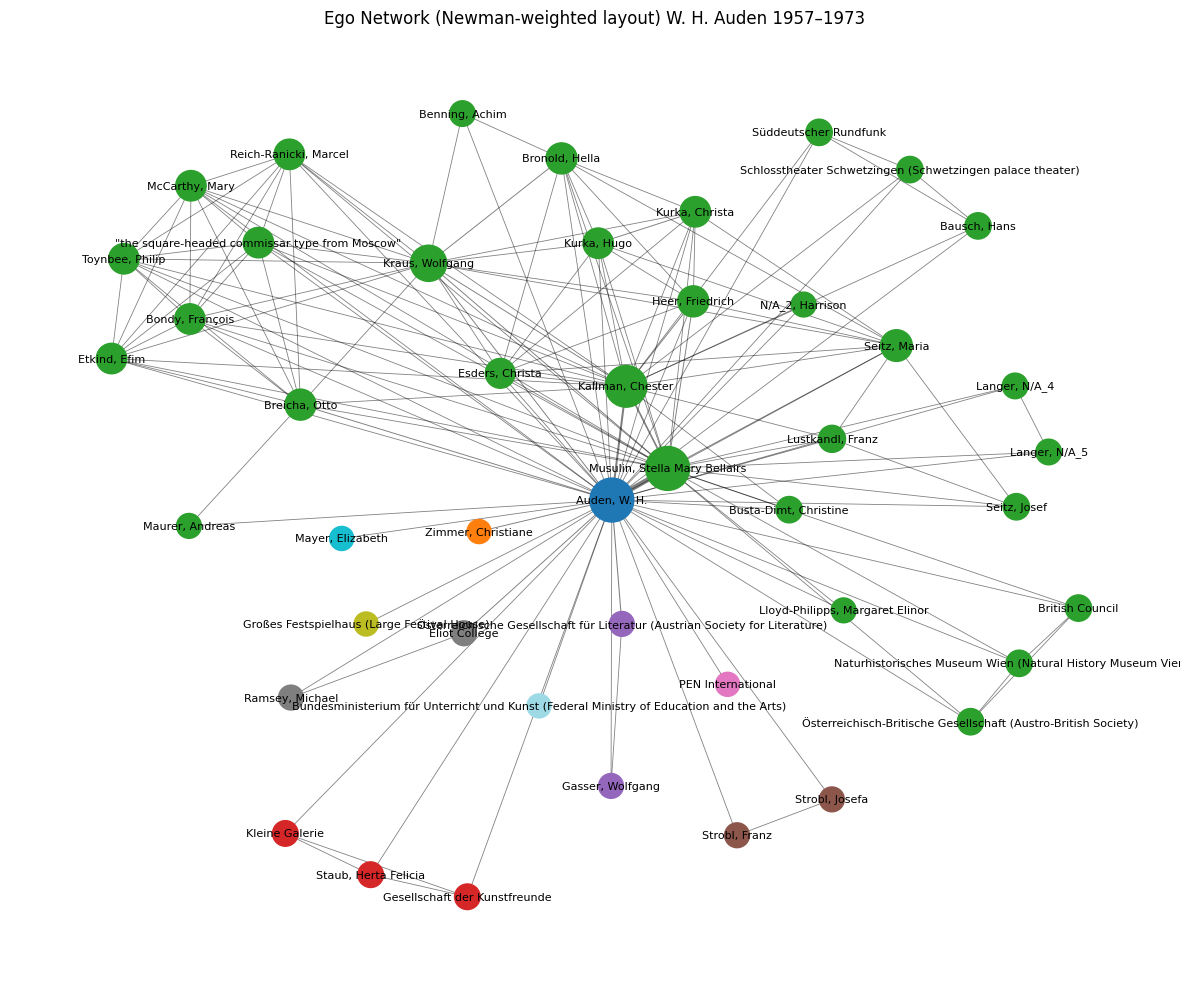

In [17]:
pos_newman = nx.spring_layout(G_newman_ego, weight='weight', seed=42)

# base layout on Newman-projected graph; preserve node size, node color, and edge width information from simple projection
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G_ego, pos_newman, node_size=node_sizes, node_color=colors, cmap=plt.cm.tab20)
nx.draw_networkx_edges(G_ego, pos_newman, width=edge_widths, alpha=0.5)
nx.draw_networkx_labels(G_ego, pos_newman, labels=name_map, font_size=8)
plt.title("Ego Network (Newman-weighted layout) W. H. Auden 1957–1973")
plt.axis('off')
plt.tight_layout()
plt.show()

The use of different projections for analysis (simple projection) and visualization (Newman's weighted projection) introduces a methodological inconsistency between the analytical and the visual results. However, the side-by-side comparison made possible by this choice has demonstrative value: it illustrates that the dense structural clustering in the simple-projection layout is partly an artifact of multi-participant event structure in the affiliation network.

Whether the Newman-style weighting's attenuating effect on cluster visualization suggests its application in the analysis of the Auden dataset is a question that is beyond the scope of the tentative approach presented in this notebook. Whereas the current descriptive objective avoids importing evidence-strength claims into reported quantities, a future analysis of the larger Auden in Austria Digital dataset may employ Newman's weighted projection to reduce how strongly large events compress small co-affiliations in the metrics.